# Model Training
***

### Project stages:
- Download prepared spectrograms from directories.
- Divide the data into train/validation/test.
- Create a simple model for classification.
- Run training and evaluate accuracy, confusion matrix, etc.
***

This code demonstrates a pipeline for training and evaluating a Convolutional Neural Network (CNN) for audio classification tasks. It covers:

Defining a custom Dataset class for loading spectrogram data.
Splitting data into training, validation, and testing sets.
Building a simple CNN model (architecture).
Training the model and saving the best checkpoint.
Evaluating the model on the test set with a confusion matrix and a classification report.

In [41]:
# Import Libs 
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
import torchvision.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

In [42]:
# Check use the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [43]:
# Path to outcome folders and metadata
OUTCOME_ROOT = "outcome"
METADATA_FILE = os.path.join(OUTCOME_ROOT, "all_metadata.csv")

BATCH_SIZE = 8
EPOCHS = 5
LEARNING_RATE = 1e-3

Sets up essential parameters such as batch size, number of epochs, learning rate, and the device for training (CUDA if available).
Points to the root directory of the outcome data (OUTCOME_ROOT) and the CSV file that holds metadata (METADATA_FILE).

### Class Spectrogram Dataset

In [44]:
class SpectrogramDataset(Dataset):
    def __init__(self, metadata_csv, root_dir=OUTCOME_ROOT, transform=None):
        """
        :param metadata_csv: path to the CSV file with metadata
        :param root_dir: root folder 'outcome'
        :param transform: (optional) torchvision transforms for spectrograms
        """
        self.df = pd.read_csv(metadata_csv)
        self.root_dir = root_dir
        self.transform = transform

        # Convert everything in "label" to str to avoid float vs. str conflict
        self.df['label'] = self.df['label'].astype(str)

        # Unique class names (in str format)
        unique_labels = self.df['label'].unique()
        unique_labels = sorted(unique_labels)

        # Create a map: label -> int
        self.label2idx = {}
        for i, lbl in enumerate(unique_labels):
            self.label2idx[lbl] = i

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # File where the spectrogram is saved
        saved_npy = row['saved_spectrogram']  # e.g.: "5713.210902110002_call_0.npy"
        label_str = row['label']             # already str

        # Search for the .npy file in each of the 4 folders:
        found_path = None
        for possible_dir in ["Grey Seal Data Additional", "Guttural rupe", "Moan", "Rupes A and B"]:
            candidate = os.path.join(self.root_dir, possible_dir, saved_npy)
            if os.path.exists(candidate):
                found_path = candidate
                break

        if found_path is None:
            raise FileNotFoundError(f"Cannot find .npy file: {saved_npy} in any subfolder.")

        # Load the 2D .npy array
        spec_data = np.load(found_path)
        # Convert to a tensor (1, freq, time)
        spec_tensor = torch.tensor(spec_data, dtype=torch.float32).unsqueeze(0)

        # Class index
        label_idx = self.label2idx[label_str]
        label_tensor = torch.tensor(label_idx, dtype=torch.long)

        # If a transformation (augmentation/normalization) is used
        if self.transform:
            spec_tensor = self.transform(spec_tensor)  # [C,H,W]

        return spec_tensor, label_tensor

### Overwiew Class Dataset

Use torch.utils.data.Dataset, where:
- Initialization reads all_metadata.csv.
- In each line: path to .npy файлу й мітка label.
- When call __getitem__, then load .np into memory, convert to a tensor and return (spectrogram_tensor, label).

In [45]:
dataset = SpectrogramDataset(metadata_csv=METADATA_FILE, root_dir=OUTCOME_ROOT, transform=None)
print("Dataset size:", len(dataset))

# Split: 70% train, 15% val, 15% test
train_size = int(0.7 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(dataset.label2idx)
print("Number of classes:", num_classes)

Dataset size: 2026
Number of classes: 19


### Model selection and setup

In [46]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # To avoid issues with dimensions, use AdaptiveAvgPool:
        # Reduce spatial dimensions to (4,4)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4,4)),  # (N,16,4,4)
            nn.Flatten(),
            nn.Linear(16*4*4, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=num_classes).to(device)

In [47]:
# Optimizer settings, loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [48]:
# Training function
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [49]:
# Valodation function
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [50]:
# Training model loop
best_val_acc = 0.0
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
    
    print(f"Epoch {epoch+1}/{EPOCHS}: "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/5: Train Loss: 1.8727 | Train Acc: 0.3272 | Val Loss: 1.8494 | Val Acc: 0.4752
Epoch 2/5: Train Loss: 1.5677 | Train Acc: 0.4020 | Val Loss: 1.7920 | Val Acc: 0.3366
Epoch 3/5: Train Loss: 1.5203 | Train Acc: 0.4401 | Val Loss: 1.6984 | Val Acc: 0.4785
Epoch 4/5: Train Loss: 1.4261 | Train Acc: 0.4880 | Val Loss: 1.7445 | Val Acc: 0.4884
Epoch 5/5: Train Loss: 1.4113 | Train Acc: 0.4965 | Val Loss: 1.6856 | Val Acc: 0.5083


In [51]:
# Evaluation on the test set
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean()
print(f"\nTest Accuracy: {accuracy:.4f}")

C:\Users\finel\AppData\Local\Temp\ipykernel_3284\3680656492.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))



Test Accuracy: 0.4885


### Correction for classification_report
***


Confusion Matrix:
[[ 0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0 76  0  1 25  0  0  0  0  0  0  0]
 [ 0  0  0  0  2  0  0  0  0  0  0  0]
 [ 0 45  0  6 11  0  0  0  0  0  0  0]
 [ 0 10  0  1 67  0  0  0  0  0  0  0]
 [ 0 15  0  0  9  0  0  0  0  0  0  0]
 [ 0  2  0  0  3  0  0  0  0  0  0  0]
 [ 0  0  0  0  2  0  0  0  0  0  0  0]
 [ 0  1  0  0  3  0  0  0  0  0  0  0]
 [ 0 16  0  0  6  0  0  0  0  0  0  0]
 [ 0  2  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  0  0  0  0]]


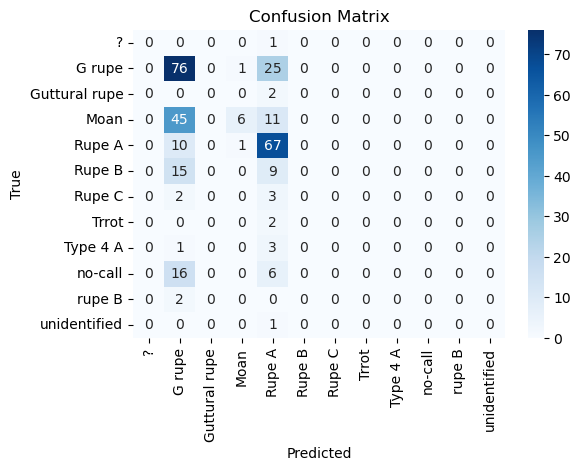


Classification Report:
               precision    recall  f1-score   support

            ?       0.00      0.00      0.00         1
       G rupe       0.46      0.75      0.57       102
Guttural rupe       0.00      0.00      0.00         2
         Moan       0.75      0.10      0.17        62
       Rupe A       0.52      0.86      0.64        78
       Rupe B       0.00      0.00      0.00        24
       Rupe C       0.00      0.00      0.00         5
        Trrot       0.00      0.00      0.00         2
     Type 4 A       0.00      0.00      0.00         4
      no-call       0.00      0.00      0.00        22
       rupe B       0.00      0.00      0.00         2
 unidentified       0.00      0.00      0.00         1

     accuracy                           0.49       305
    macro avg       0.14      0.14      0.12       305
 weighted avg       0.44      0.49      0.39       305



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
# Identify which classes actually occurred in the arrays:
used_labels = np.unique(np.concatenate([all_labels, all_preds]))
idx2label = {v: k for k, v in dataset.label2idx.items()}

# Build target_names only for these used_labels
target_names = [idx2label[i] for i in used_labels]

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds, labels=used_labels)
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Now we pass labels=used_labels, target_names=... to classification_report
print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    labels=used_labels,
    target_names=target_names
))

## Conclusions Based on the Results
***
### Overall Accuracy

The reported test accuracy is around 48%, indicating that while the model learns some distinctions, it still struggles to correctly classify many samples.
Class Imbalance

The confusion matrix reveals that most predictions are dominated by one or two classes (e.g., "G rupe" or "Rupe A"), suggesting potential class imbalance in the training data or difficulty in distinguishing less frequent classes.
Precision-Recall Trade-off

Some classes (like "G rupe") may have a high recall but lower precision, meaning the model often classifies everything as "G rupe," causing incorrect predictions for many other classes.
Potential Improvements

Collect more balanced data or apply techniques like oversampling/undersampling or data augmentation for minority classes.
Adopt more advanced architectures (e.g., ResNet, EfficientNet) or use pre-trained audio embeddings to capture more complex patterns.
Hyperparameter tuning (learning rate, number of epochs, batch size) to enhance model generalization.
Augmentations (time shift, frequency masking, etc.) to increase model robustness to variations in audio signals.
Future Work

### Consider analyzing individual classes in more detail.
Explore techniques like transfer learning using pre-trained models for audio/sound classification.
Implement more systematic error analysis to pinpoint exactly where and why the model confuses certain classes.
Overall, the current SimpleCNN approach provides a good starting point but requires further optimization, improved data representation, and potentially deeper architectures to achieve better classification performance across all classes.